## Manuscript figures
### "Narrowing the gap between ML scoring functions and FEP using augmented data"


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import sys
from scipy.stats import pearsonr, kendalltau
from sklearn.metrics import mean_squared_error
import os

In [2]:
import matplotlib as mpl
mpl.rcParams['savefig.dpi'] = 600
mpl.rcParams['font.size'] = 10

In [3]:
def rmse(true, pred):
    return np.sqrt(mean_squared_error(true, pred))

def pk_to_dg(pk):
    r = 8.3145  # J/mol/K
    t = 297  # K
    k = 10**-pk
    dg_j = r * t * np.log(k)  # Natural log
    dg_kcal = dg_j / 4184
    return dg_kcal

### Main paper

#### Figure 1: AEV-PLIG model schematic

Created separately.

#### Figure 2: AEV-PLIG baseline performance

In [9]:
def format_marginal(ax, horizontal=True):
        ax.set_xticks([])
        ax.set_yticks([])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        if horizontal:
            ax.spines['left'].set_visible(False)
            ax.invert_xaxis()
            
        else:
            ax.spines['bottom'].set_visible(False)
            ax.invert_yaxis()

        ax.set_ylabel('')
        ax.set_xlabel('')

def plot_scatter_with_marginals(df1, df2, x_col, y_col, outpath=None):

    fig = plt.figure(figsize=(4, 7), constrained_layout=True)

    widths = [4, 0.6]
    heights = [0.6, 4, 0.6, 4]
    lims = [-16, -2]

    spec = fig.add_gridspec(ncols=2, nrows=4, width_ratios=widths,
                        height_ratios=heights)
    
    # Dotted x=y line
    ax1 = fig.add_subplot(spec[1, 0])
    ax1.plot(lims, lims, linestyle='--', color='gray', alpha=0.7)

    ax2 = fig.add_subplot(spec[3, 0])
    ax2.plot(lims, lims, linestyle='--', color='gray', alpha=0.7)

    # Scatter plots
    sns.scatterplot(data=df1, x=x_col, y=y_col, color='darkorange', ax=ax1, legend=False, edgecolor='black', alpha=0.6, zorder=10)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.set_xlabel('')
    ax1.set_ylabel(r'Pred. $\Delta$G (kcal/mol)')
    ax1.set_xticks([-16,-12,-8,-4])

    sns.scatterplot(data=df2, x=x_col, y=y_col, color='forestgreen', ax=ax2, legend=False,  edgecolor='black', alpha=0.6, zorder=10)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.set_xlabel(r'Exp. $\Delta$G (kcal/mol)')
    ax2.set_ylabel(r'Pred. $\Delta$G (kcal/mol)')
    ax2.set_xticks(np.arange(lims[0],lims[1],-2))
    ax2.set_xticks([-16,-12,-8,-4])

    # Marginal histograms (remove labels, ticks and boxes)
    ax1_marg_x = fig.add_subplot(spec[0, 0])
    sns.kdeplot(data=df1, x=x_col, color='darkorange', ax=ax1_marg_x, legend=False)
    format_marginal(ax1_marg_x)
    ax1_marg_x.set_xlim(lims)
    
    ax1_marg_y = fig.add_subplot(spec[1, 1])
    sns.kdeplot(data=df1, y=y_col, color='darkorange', ax=ax1_marg_y, legend=False)
    format_marginal(ax1_marg_y, horizontal=False)
    ax1_marg_y.set_ylim(lims)

    ax2_marg_x = fig.add_subplot(spec[2, 0])
    sns.kdeplot(data=df2, x=x_col, color='forestgreen', ax=ax2_marg_x, legend=False)
    format_marginal(ax2_marg_x)
    ax2_marg_x.set_xlim(lims)

    ax2_marg_y = fig.add_subplot(spec[3, 1])
    sns.kdeplot(data=df2, y=y_col, color='forestgreen', ax=ax2_marg_y, legend=False)
    format_marginal(ax2_marg_y, horizontal=False)
    ax2_marg_y.set_ylim(lims)

    # Annotations
    ax1.set_title('a)', loc='left', position=(-0.2, 1.0), fontsize=12)
    ax2.set_title('b)', loc='left', position=(-0.2, 1.0), fontsize=12)

    ax1_pcc, ax1_kt, ax1_rmse = pearsonr(df1[x_col], df1[y_col])[0], kendalltau(df1[x_col], df1[y_col])[0], rmse(df1[x_col], df1[y_col])
    ax2_pcc, ax2_kt, ax2_rmse = pearsonr(df2[x_col], df2[y_col])[0], kendalltau(df2[x_col], df2[y_col])[0], rmse(df2[x_col], df2[y_col])
    ax1.text(-16, -4, f'PCC = {ax1_pcc:.2f}\n'+r'K$\tau$ = '+f'{ax1_kt:.2f}\nRMSE = {ax1_rmse:.2f}', fontsize=9)
    ax2.text(-16, -4, f'PCC = {ax2_pcc:.2f}\n'+r'K$\tau$ = '+f'{ax2_kt:.2f}\nRMSE = {ax2_rmse:.2f}', fontsize=9)

    if outpath:
        plt.tight_layout(w_pad=1, h_pad=0)
        plt.savefig(outpath, bbox_inches='tight')

In [18]:
ood_baseline_predictions = pd.read_csv("data/baseline/AEV-PLIG_oodtest_predictions.csv")
ood_baseline_predictions['Exp. ΔG'] = [pk_to_dg(pk) for pk in ood_baseline_predictions['pK']]
ood_baseline_predictions['preds'] = [pk_to_dg(pk) for pk in ood_baseline_predictions['preds']]

casf16_baseline_predictions = pd.read_csv("data/baseline/AEV-PLIG_casf2016_pdbbind_predictions.csv")
casf16_baseline_predictions['Exp. ΔG'] = [pk_to_dg(pk) for pk in casf16_baseline_predictions['truth']]
casf16_baseline_predictions['preds'] = [pk_to_dg(pk) for pk in casf16_baseline_predictions['preds']]

/var/folders/n0/jnvj1pls2_5_j5b80078qmx40000gn/T/ipykernel_42805/1022950617.py:83: UserWarning: The figure layout has changed to tight
  plt.tight_layout(w_pad=1, h_pad=0)


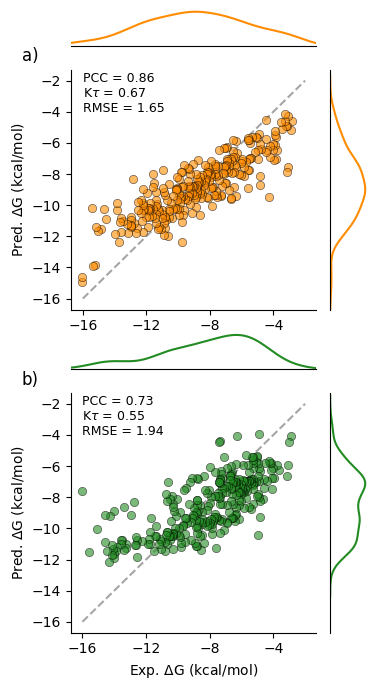

In [20]:
plot_scatter_with_marginals(casf16_baseline_predictions, ood_baseline_predictions, 'Exp. ΔG', 'preds', 'figures/figure2.png')

#### Figure 3: AEV-PLIG with augmented training data performance

In [10]:
def weighted_mean(num_per_set, value_per_set):
    return np.sum(num_per_set*value_per_set) / np.sum(num_per_set)

def get_bootstrap_weighted_value(num_set, value_set, nboots=10000):
    value_samples = np.zeros(nboots)
    for b in range(nboots):
        inds = np.random.choice(len(value_set), len(value_set))
        value_samples[b] = weighted_mean(num_set[inds], value_set[inds])
    return np.percentile(value_samples, 2.5), np.percentile(value_samples, 97.5)

def get_weighted_stats(results, preds_col, truth_col, groups):
    results["pred"] = results[preds_col]
    results["truth"] = results[truth_col]

    logs = []
    for target in groups:
        subset = results[results["group_id"] == target]
        logs.append(
            [
                target,
                pearsonr(subset["pred"], subset["truth"])[0],
                kendalltau(subset["pred"], subset["truth"])[0],
                rmse(subset["pred"], subset["truth"]),
                len(subset),
            ]
        )

    performance = pd.DataFrame(
        logs, columns=["Target", "Pearson's R", "Kendall's Tau", "RMSE", "Sample size"]
    )

    wpcc = weighted_mean(np.array(performance["Sample size"]), np.array(performance["Pearson's R"]))
    wpcc_low, wpcc_high = get_bootstrap_weighted_value(np.array(performance["Sample size"]), np.array(performance["Pearson's R"]))
    wktau = weighted_mean(np.array(performance["Sample size"]), np.array(performance["Kendall's Tau"]))
    wktau_low, wktau_high = get_bootstrap_weighted_value(np.array(performance["Sample size"]), np.array(performance["Kendall's Tau"]))

    return wpcc, wpcc_low, wpcc_high, wktau, wktau_low, wktau_high

def lineplot_with_error_bars(
    fep_pcc_data,
    fep_ktau_data,
    df,
    df_baseline,
    label_fep,
    label,
    label_baseline,
    pcc_lims,
    ktau_lims,
    pcc_ticks,
    ktau_ticks,
    xlabel,
    invert_xaxis=False,
    outpath=None,
):
    color = "steelblue"
    color_baseline = "green"
    color_fep = "firebrick"

    fig = plt.figure(figsize=(4, 8))
    gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1])

    ax1 = plt.subplot(gs[0])
    ax2 = plt.subplot(gs[1], sharex=ax1)

    # plot PCC data
    ax1.axhline(y=fep_pcc_data[0], color=color_fep, linestyle="--", label=label_fep, lw=2)
    ax1.axhspan(ymin=fep_pcc_data[1], ymax=fep_pcc_data[2], facecolor=color_fep, edgecolor=None, alpha=0.3)

    sns.lineplot(
        data = df,
        x="Tanimoto",
        y="WPCC",
        label=label,
        color=color,
        marker="o",
        ms=10,
        lw=2,
        markeredgecolor="black",
        markeredgewidth=1.1,
        ax=ax1
    )
    errors = np.array([df["WPCC"] - df["WPCC_low"], df["WPCC_high"] - df["WPCC"]])
    ax1.errorbar(df["Tanimoto"], df["WPCC"], yerr=errors, fmt='o', capsize=4, elinewidth=1.5, ecolor=color, capthick=1.5, zorder=0)

    sns.lineplot(
        data = df_baseline,
        x="Tanimoto",
        y="WPCC",
        label=label_baseline,
        color=color_baseline,
        marker="o",
        ms=10,
        lw=2,
        markeredgecolor="black",
        markeredgewidth=1.1,
        ax=ax1
    )
    errors = np.array([df_baseline["WPCC"] - df_baseline["WPCC_low"], df_baseline["WPCC_high"] - df_baseline["WPCC"]])
    ax1.errorbar(df_baseline["Tanimoto"], df_baseline["WPCC"], yerr=errors, fmt='o', capsize=4, elinewidth=1.5, ecolor=color_baseline, capthick=1.5, zorder=0)

    # plot Ktau data
    ax2.axhline(y=fep_ktau_data[0], color=color_fep, linestyle="--", lw=2)
    ax2.axhspan(ymin=fep_ktau_data[1], ymax=fep_ktau_data[2], facecolor=color_fep, edgecolor=None, alpha=0.3)

    sns.lineplot(
        data = df,
        x="Tanimoto",
        y="WKtau",
        color=color,
        marker="o",
        ms=10,
        lw=2,
        markeredgecolor="black",
        markeredgewidth=1.1,
        ax=ax2,
        legend=False
    )
    errors = np.array([df["WKtau"] - df["WKtau_low"], df["WKtau_high"] - df["WKtau"]])
    ax2.errorbar(df["Tanimoto"], df["WKtau"], yerr=errors, fmt='o', capsize=4, elinewidth=1.5, ecolor=color, capthick=1.5, zorder=0)

    sns.lineplot(
        data = df_baseline,
        x="Tanimoto",
        y="WKtau",
        color=color_baseline,
        marker="o",
        ms=10,
        lw=2,
        markeredgecolor="black",
        markeredgewidth=1.1,
        ax=ax2,
        legend=False
    )

    errors = np.array([df_baseline["WKtau"] - df_baseline["WKtau_low"], df_baseline["WKtau_high"] - df_baseline["WKtau"]])
    ax2.errorbar(df_baseline["Tanimoto"], df_baseline["WKtau"], yerr=errors, fmt='o', capsize=4, elinewidth=1.5, ecolor=color_baseline, capthick=1.5, zorder=0)

    ax1.set_ylabel("Weighted mean PCC")
    ax1.set_xlabel("")
    ax1.set_ylim(pcc_lims)
    if invert_xaxis:
        ax1.invert_xaxis()
    ax1.set_yticks(pcc_ticks)
    ax1.set_xticks([0.9, 0.8, 0.7, 0.6])
    ax1.set_title("a)", loc="left", fontsize=14, position=(-0.25, 1.0))

    ax2.set_xlabel(xlabel)
    ax2.set_ylabel(r"Weighted mean K$\tau$")
    ax2.set_ylim(ktau_lims)
    ax2.set_yticks(ktau_ticks)
    ax2.set_xticks([0.9, 0.8, 0.7, 0.6])
    ax2.set_title("b)", loc="left", fontsize=14, position=(-0.25, 1.0))

    ax1.legend(bbox_to_anchor=(0.5, 1.25), loc="center", frameon=False)

    plt.tight_layout()

    if outpath:
        plt.savefig(outpath)

In [26]:
# FEP+
results = pd.read_csv("data/fep/fep_benchmark_fep+_predictions.csv", index_col=0)
counts = pd.DataFrame(results["group_id"].value_counts())
groups = list(counts[counts["count"] >= 10].index)
fep_wpcc, fep_wpcc_low, fep_wpcc_high, fep_wktau, fep_wktau_low, fep_wktau_high = get_weighted_stats(results, 'Pred. dG (kcal/mol)', 'Exp. dG (kcal/mol)', groups)

fep_index = results[["graph_id", "Exp. dG (kcal/mol)"]]
fep_index = fep_index.rename(columns={"graph_id":"unique_id"})

# AEV-PLIG baseline
results = pd.read_csv("data/baseline/AEV-PLIG_fep_benchmark_pdbbind_ligsim90_predictions.csv")
results["preds"] = [pk_to_dg(pk) for pk in results["preds"]]
results = results.merge(fep_index, how="left", on="unique_id")
baseline_ls90_wpcc, baseline_ls90_wpcc_low, baseline_ls90_wpcc_high, baseline_ls90_wktau, baseline_ls90_wktau_low, baseline_ls90_wktau_high = get_weighted_stats(results, 'preds', 'Exp. dG (kcal/mol)', groups)

results = pd.read_csv("data/baseline/AEV-PLIG_fep_benchmark_pdbbind_ligsim80_predictions.csv")
results["preds"] = [pk_to_dg(pk) for pk in results["preds"]]
results = results.merge(fep_index, how="left", on="unique_id")
baseline_ls80_wpcc, baseline_ls80_wpcc_low, baseline_ls80_wpcc_high, baseline_ls80_wktau, baseline_ls80_wktau_low, baseline_ls80_wktau_high = get_weighted_stats(results, 'preds', 'Exp. dG (kcal/mol)', groups)

results = pd.read_csv("data/baseline/AEV-PLIG_fep_benchmark_pdbbind_ligsim70_predictions.csv")
results["preds"] = [pk_to_dg(pk) for pk in results["preds"]]
results = results.merge(fep_index, how="left", on="unique_id")
baseline_ls70_wpcc, baseline_ls70_wpcc_low, baseline_ls70_wpcc_high, baseline_ls70_wktau, baseline_ls70_wktau_low, baseline_ls70_wktau_high = get_weighted_stats(results, 'preds', 'Exp. dG (kcal/mol)', groups)

results = pd.read_csv("data/baseline/AEV-PLIG_fep_benchmark_pdbbind_ligsim60_predictions.csv")
results["preds"] = [pk_to_dg(pk) for pk in results["preds"]]
results = results.merge(fep_index, how="left", on="unique_id")
baseline_ls60_wpcc, baseline_ls60_wpcc_low, baseline_ls60_wpcc_high, baseline_ls60_wktau, baseline_ls60_wktau_low, baseline_ls60_wktau_high = get_weighted_stats(results, 'preds', 'Exp. dG (kcal/mol)', groups)

# AEV-PLIG with PDBbind + BindingNet + BindingDB
results = pd.read_csv("data/bindingnet_bindingdb/AEV-PLIG_fep_benchmark_pdbbind_U_bindingnet_U_bindingdb_ligsim90_predictions.csv")
results["preds"] = [pk_to_dg(pk) for pk in results["preds"]]
results = results.merge(fep_index, how="left", on="unique_id")
bindingnet_bindingdb_ls90_wpcc, bindingnet_bindingdb_ls90_wpcc_low, bindingnet_bindingdb_ls90_wpcc_high, bindingnet_bindingdb_ls90_wktau, bindingnet_bindingdb_ls90_wktau_low, bindingnet_bindingdb_ls90_wktau_high  = get_weighted_stats(results, 'preds', 'Exp. dG (kcal/mol)', groups)

results = pd.read_csv("data/bindingnet_bindingdb/AEV-PLIG_fep_benchmark_pdbbind_U_bindingnet_U_bindingdb_ligsim80_predictions.csv")
results["preds"] = [pk_to_dg(pk) for pk in results["preds"]]
results = results.merge(fep_index, how="left", on="unique_id")
bindingnet_bindingdb_ls80_wpcc, bindingnet_bindingdb_ls80_wpcc_low, bindingnet_bindingdb_ls80_wpcc_high, bindingnet_bindingdb_ls80_wktau, bindingnet_bindingdb_ls80_wktau_low, bindingnet_bindingdb_ls80_wktau_high  = get_weighted_stats(results, 'preds', 'Exp. dG (kcal/mol)', groups)

results = pd.read_csv("data/bindingnet_bindingdb/AEV-PLIG_fep_benchmark_pdbbind_U_bindingnet_U_bindingdb_ligsim70_predictions.csv")
results["preds"] = [pk_to_dg(pk) for pk in results["preds"]]
results = results.merge(fep_index, how="left", on="unique_id")
bindingnet_bindingdb_ls70_wpcc, bindingnet_bindingdb_ls70_wpcc_low, bindingnet_bindingdb_ls70_wpcc_high, bindingnet_bindingdb_ls70_wktau, bindingnet_bindingdb_ls70_wktau_low, bindingnet_bindingdb_ls70_wktau_high  = get_weighted_stats(results, 'preds', 'Exp. dG (kcal/mol)', groups)

results = pd.read_csv("data/bindingnet_bindingdb/AEV-PLIG_fep_benchmark_pdbbind_U_bindingnet_U_bindingdb_ligsim60_predictions.csv")
results["preds"] = [pk_to_dg(pk) for pk in results["preds"]]
results = results.merge(fep_index, how="left", on="unique_id")
bindingnet_bindingdb_ls60_wpcc, bindingnet_bindingdb_ls60_wpcc_low, bindingnet_bindingdb_ls60_wpcc_high, bindingnet_bindingdb_ls60_wktau, bindingnet_bindingdb_ls60_wktau_low, bindingnet_bindingdb_ls60_wktau_high  = get_weighted_stats(results, 'preds', 'Exp. dG (kcal/mol)', groups)

df = pd.DataFrame(
    {
        "Tanimoto": [0.9, 0.8, 0.7, 0.6],
        "WPCC": [bindingnet_bindingdb_ls90_wpcc, bindingnet_bindingdb_ls80_wpcc, bindingnet_bindingdb_ls70_wpcc, bindingnet_bindingdb_ls70_wpcc],
        "WPCC_low": [bindingnet_bindingdb_ls90_wpcc_low, bindingnet_bindingdb_ls80_wpcc_low, bindingnet_bindingdb_ls70_wpcc_low, bindingnet_bindingdb_ls70_wpcc_low],
        "WPCC_high": [bindingnet_bindingdb_ls90_wpcc_high, bindingnet_bindingdb_ls80_wpcc_high, bindingnet_bindingdb_ls70_wpcc_high, bindingnet_bindingdb_ls70_wpcc_high],
        "WKtau": [bindingnet_bindingdb_ls90_wktau, bindingnet_bindingdb_ls80_wktau, bindingnet_bindingdb_ls70_wktau, bindingnet_bindingdb_ls60_wktau],
        "WKtau_low": [bindingnet_bindingdb_ls90_wktau_low, bindingnet_bindingdb_ls80_wktau_low, bindingnet_bindingdb_ls70_wktau_low, bindingnet_bindingdb_ls60_wktau_low],
        "WKtau_high": [bindingnet_bindingdb_ls90_wktau_high, bindingnet_bindingdb_ls80_wktau_high, bindingnet_bindingdb_ls70_wktau_high, bindingnet_bindingdb_ls60_wktau_high],
    }
)

df_baseline = pd.DataFrame(
    {
        "Tanimoto": [0.9, 0.8, 0.7, 0.6],
        "WPCC": [baseline_ls90_wpcc, baseline_ls80_wpcc, baseline_ls70_wpcc, baseline_ls60_wpcc],
        "WPCC_low": [baseline_ls90_wpcc_low, baseline_ls80_wpcc_low, baseline_ls70_wpcc_low, baseline_ls60_wpcc_low],
        "WPCC_high": [baseline_ls90_wpcc_high, baseline_ls80_wpcc_high, baseline_ls70_wpcc_high, baseline_ls60_wpcc_high],
        "WKtau": [baseline_ls90_wktau, baseline_ls80_wktau, baseline_ls70_wktau, baseline_ls60_wktau],
        "WKtau_low": [baseline_ls90_wktau_low, baseline_ls80_wktau_low, baseline_ls70_wktau_low, baseline_ls60_wktau_low],
        "WKtau_high": [baseline_ls90_wktau_high, baseline_ls80_wktau_high, baseline_ls70_wktau_high, baseline_ls60_wktau_high],
    }
)

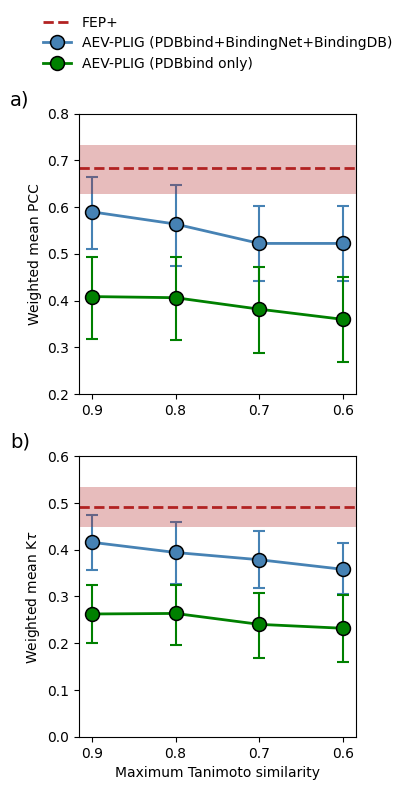

In [27]:
lineplot_with_error_bars(
    [fep_wpcc, fep_wpcc_low, fep_wpcc_high],
    [fep_wktau, fep_wktau_low, fep_wktau_high],
    df,
    df_baseline,
    "FEP+",
    "AEV-PLIG (PDBbind+BindingNet+BindingDB)",
    "AEV-PLIG (PDBbind only)",
    [0.2, 0.8],
    [0.0, 0.6],
    [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
    [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6],
    xlabel="Maximum Tanimoto similarity",
    invert_xaxis=True,
    outpath="figures/figure3.png",
)

#### Figure 4: AEV-PLIG vs FEP+ barplot

In [11]:
def get_performance_df(results, preds_col, truth_col, groups):
    results["pred"] = results[preds_col]
    results["truth"] = results[truth_col]

    logs = []
    for target in groups:
        subset = results[results["group_id"] == target]
        logs.append(
            [
                target,
                pearsonr(subset["pred"], subset["truth"])[0],
                kendalltau(subset["pred"], subset["truth"])[0],
                rmse(subset["pred"], subset["truth"]),
                len(subset),
            ]
        )

    performance = pd.DataFrame(
        logs, columns=["Target", "Pearson's R", "Kendall's Tau", "RMSE", "Sample size"]
    )
    return performance

def plot_bars_comparison(
    df1,
    df2,
    column1,
    column2,
    xlabel='',
    y1_label='',
    y2_label='',
    y1_lim=(0, 1),
    y2_lim=(0, 2),
    signif_pairs_ax1=None,
    signif_pairs_ax2=None,
    signif_level_ax1=None,
    signif_level_ax2=None,
    outpath=None
):

    color = "steelblue"
    color_fep = "indianred"

    labels = df1.Target
    x = list(range(len(labels)))
    bar_width = 0.35

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True, constrained_layout=True)

    bars1_ax1 = ax1.bar(
        x,
        df1[column1],
        bar_width,
        label='AEV-PLIG (PDBbind+BindingNet+BindingDB-DCS)',
        facecolor=color,
        edgecolor='black'
    )
    bars2_ax1 = ax1.bar(
        [i + bar_width for i in x],
        df2[column1],
        bar_width,
        label='FEP+',
        facecolor=color_fep,
        edgecolor='black'
    )

    bars1_ax2 = ax2.bar(
        x,
        df1[column2],
        bar_width,
        label='AEV-PLIG (PDBbind+BindingNet+BindingDB-DCS)',
        facecolor=color,
        edgecolor='black'
    )
    bars2_ax2 = ax2.bar(
        [i + bar_width for i in x],
        df2[column2],
        bar_width,
        label='FEP+',
        facecolor=color_fep,
        edgecolor='black'
    )

    ax1.set_ylim(y1_lim)
    ax2.set_ylim(y2_lim)

    ax1.set_xlim((x[0] - 1.5 * bar_width, x[-1] + 2.5 * bar_width))
    ax2.set_xlim((x[0] - 1.5 * bar_width, x[-1] + 2.5 * bar_width))

    ax2.set_xlabel(xlabel, labelpad=10)
    ax1.set_ylabel(y1_label)
    ax2.set_ylabel(y2_label)

    ax1.set_xticks([i + bar_width / 2 for i in x])
    ax1.set_xticklabels([])
    ax2.set_xticks([i + bar_width / 2 for i in x])
    ax2.set_xticklabels(labels, rotation=90)
    
    ax1.legend(ncol=2, frameon=False, loc='upper left', bbox_to_anchor=(0.2, 1.25))

    ax1.set_title("a)", loc="left", fontsize=14, position=(-0.08, 1))
    ax2.set_title("b)", loc="left", fontsize=14, position=(-0.08, 1))

    def add_significance(ax, bars1, bars2, signif_pairs, signif_level, offset=0.03, line_height=0.02, fontsize=12):
    
        if signif_pairs is None:
            return

        assert len(signif_pairs) == len(signif_level)

        x = np.arange(len(bars1))
        y_max = max([bar.get_height() for bar in bars1 + bars2])
        y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
        
        for i, diff in enumerate(signif_pairs):
            level = signif_level[i]
            
            if level == 1:
                star = "*"
            elif level == 2:
                star = "**"
            elif level == 3:
                star = "***"
            else:
                star = ""

            if diff:
                bar1 = bars1[x[i]]
                bar2 = bars2[x[i]]
                x1 = bar1.get_x() + bar1.get_width() / 2
                x2 = bar2.get_x() + bar2.get_width() / 2
                y1 = bar1.get_height()
                y2 = bar2.get_height()
                y = max(y1, y2) + offset * y_range

                ax.plot([x1, x1, x2, x2], [y, y + line_height * y_range, y + line_height * y_range, y], lw=1, color='black')
                ax.text((x1 + x2) / 2, y + line_height/4 * y_range, star, ha='center', va='bottom', color='black', fontsize=fontsize)
            

    add_significance(ax1, bars1_ax1, bars2_ax1, signif_pairs_ax1, signif_level_ax1)
    add_significance(ax2, bars1_ax2, bars2_ax2, signif_pairs_ax2, signif_level_ax2)

    plt.tight_layout()

    if outpath:
        plt.savefig(outpath, dpi=500, bbox_inches='tight')

In [32]:
# load FEP+ results
results = pd.read_csv("data/fep/fep_benchmark_fep+_predictions.csv", index_col=0)
counts = pd.DataFrame(results["group_id"].value_counts())
groups = list(counts[counts["count"] >= 25].index)
groups.remove("jacs_set/bace")
fep_index = results[["graph_id", "Exp. dG (kcal/mol)"]]
fep_index = fep_index.rename(columns={"graph_id":"unique_id"})
performance_fep = get_performance_df(results, "Pred. dG (kcal/mol)", "Exp. dG (kcal/mol)", groups)

# load AEV-PLIG results
results = pd.read_csv("data/bindingnet_bindingdb/AEV-PLIG_fep_benchmark_pdbbind_U_bindingnet_U_bindingdb_ligsim90_predictions.csv")
results["preds"] = [pk_to_dg(pk) for pk in results["preds"]]
results = results.merge(fep_index, how="left", on="unique_id")
performance_aevplig = get_performance_df(results, "preds", "Exp. dG (kcal/mol)", groups)

# baseline AEV-PLIG
results = pd.read_csv("data/baseline/AEV-PLIG_fep_benchmark_pdbbind_ligsim90_predictions.csv")
results["preds"] = [pk_to_dg(pk) for pk in results["preds"]]
results = results.merge(fep_index, how="left", on="unique_id")
performance_baseline = get_performance_df(results, "preds", "Exp. dG (kcal/mol)", groups)

# Change Target names
target_dict = {
    "gpcrs/ox2_hip_custcore": "OX2",
    "merck/syk_4puz_fullmap": "SYK",
    "jacs_set/mcl1_extra_flips": "Mcl1",
    "merck/hif2a_automap": "HIF2α",
    "merck/pfkfb3_automap": "PFKFB3",
    "jacs_set/p38": "p38",
    "merck/eg5_extraprotomers": "Eg5",
    "janssen_bace/bace_ciordia_retro": "BACE1",
    "merck/tnks2_fullmap": "TNKS2",
    "merck/cdk8_5cei_new_helix_loop_extra": "CDK8",
    "mcs_docking/renin_customcore": "Renin",
    "opls_stress/fxa_yoshikawa_set": "Factor Xa",
    "misc/galectin3_extra": "Galectin",
    "merck/shp2": "SHP-2",
}

performance_fep["Target"] = performance_fep["Target"].map(target_dict)
performance_aevplig["Target"] = performance_aevplig["Target"].map(target_dict)
performance_baseline["Target"] = performance_baseline["Target"].map(target_dict)

# Define significance
pcc_sig_diff = {
    "OX2" : True,
    "SYK" : False,
    "Mcl1" : False,
    "HIF2α" : True,
    "PFKFB3" : True,
    "p38" : False,
    "Eg5" : False,
    "BACE1" : True,
    "TNKS2" : False,
    "CDK8" : False,
    "Renin" : False,
    "Factor Xa" : False,
    "Galectin" : True,
    "SHP-2" : True
}

ktau_sig_diff = {
    "OX2" : True,
    "SYK" : False,
    "Mcl1" : False,
    "HIF2α" : False,
    "PFKFB3" : True,
    "p38" : False,
    "Eg5" : False,
    "BACE1" : True,
    "TNKS2" : False,
    "CDK8" : False,
    "Renin" : False,
    "Factor Xa" : False,
    "Galectin" : False,
    "SHP-2" : False
}

/var/folders/n0/jnvj1pls2_5_j5b80078qmx40000gn/T/ipykernel_42805/220461159.py:142: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


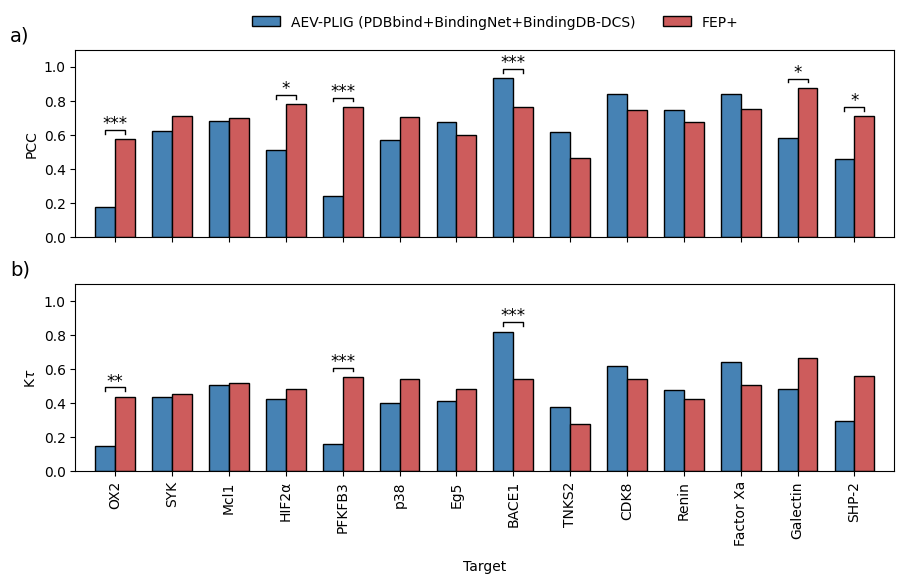

In [34]:
plot_bars_comparison(
    performance_aevplig,
    performance_fep,
    "Pearson's R",
    "Kendall's Tau",
    xlabel="Target",
    y1_label="PCC",
    y2_label=r"K$\tau$",
    y1_lim=(0, 1.1),
    y2_lim=(0, 1.1),
    signif_pairs_ax1=pcc_sig_diff.values(),
    signif_pairs_ax2=ktau_sig_diff.values(),
    signif_level_ax1 = [3,0,0,1,3,0,0,3,0,0,0,0,1,1],
    signif_level_ax2 = [2,0,0,0,3,0,0,3,0,0,0,0,0,0],
    outpath="figures/figure4.png",
)

#### Figure 5: AEV radial components

In [39]:
def cutoff_fn_ANI(x, Rc):
    return 0.5 * np.cos(np.pi * (x / Rc)) + 0.5

def radial_ANI(x, Rc, Eta, Rs):
    return np.exp(-Eta * (x - Rs)**2) * cutoff_fn_ANI(x, Rc)

RcR = 5.1
EtaR = 19.7
RsR_vec = [0.80, 1.34, 1.88, 2.41, 2.95, 3.49, 4.03, 4.56]

def plot_radial_aevs(RcR, EtaR, RsR_vec, outpath=None):
    
    R = np.arange(0, RcR + 0.01, 0.01)
    data = {'R': R}

    for RsR in RsR_vec:
        col_name = f"{RsR:.2f}"
        data[col_name] = radial_ANI(R, RcR, EtaR, RsR)

    data_long = pd.melt(pd.DataFrame(data), id_vars='R', var_name='Center', value_name='value')

    plt.figure(figsize=(6, 3))

    sns.lineplot(data=data_long, x='R', y='value', hue='Center', linewidth=1.5)

    plt.ylabel(r'$C(R_{ij})$')
    plt.xlabel(r'$R_{ij}\ (\AA)$')
    plt.legend(title=r"R$_s$ ($\AA$)", title_fontsize='10', fontsize='9', frameon=False)

    if outpath:
        plt.savefig(outpath, bbox_inches='tight')

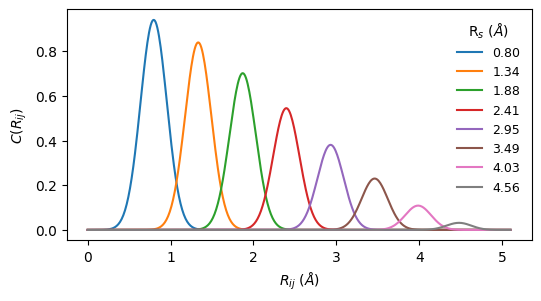

In [40]:
plot_radial_aevs(RcR, EtaR, RsR_vec, outpath='figures/figure5.png')

## Supplementary Figures

#### Figure S2: AEV-PLIG vs FEP+ performance for series with 10 or more ligands

In [36]:
def plot_dot_plot(systems, fep_data, aevplig_data, baseline_data, outpath=None):
    
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10, 14), sharey=True, constrained_layout=True)
    y = np.arange(0, len(systems), 1)

    # Sort each dataset by system alphabetically
    fep_data = fep_data.sort_values("Target")
    aevplig_data = aevplig_data.sort_values("Target")
    baseline_data = baseline_data.sort_values("Target")

    # plot FEP+ data on the left axis
    ax1.scatter(
        fep_data["Pearson's R"],
        y,
        color="indianred",
        label="FEP+",
        alpha=1,
        marker='^',
        s=50,
    )

    ax2.scatter(
        fep_data["Kendall's Tau"],
        y,
        color="indianred",
        label="FEP+",
        alpha=1,
        marker='^',
        s=50,
    )

    # plot AEV-PLIG data
    ax1.scatter(
        aevplig_data["Pearson's R"],
        y,
        color="steelblue",
        label="AEV-PLIG (PDBbind+BindingNet+BindingDB)",
        alpha=0.8,
        marker='o',
        s=30
    )

    ax2.scatter(
        aevplig_data["Kendall's Tau"],
        y,
        color="steelblue",
        label="AEV-PLIG (PDBbind+BindingNet+BindingDB)",
        alpha=0.8,
        marker='o',
        s=30
    )

    ax1.scatter(
        baseline_data["Pearson's R"],
        y,
        color="green",
        label="AEV-PLIG (PDBbind only)",
        alpha=0.8,
        marker='o',
        s=30,
    )

    ax2.scatter(
        baseline_data["Kendall's Tau"],
        y,
        color="green",
        label="AEV-PLIG (PDBbind only)",
        alpha=0.8,
        marker='o',
        s=30
    )

    # Draw a grey line between the baseline and AEV-PLIG data
    for i in range(len(systems)):
        ax1.plot(
            [baseline_data["Pearson's R"].iloc[i], aevplig_data["Pearson's R"].iloc[i]],
            [y[i], y[i]],
            color="black",
            linestyle=":",
            alpha=0.9,
            zorder=0,
        )
        ax2.plot(
            [baseline_data["Kendall's Tau"].iloc[i], aevplig_data["Kendall's Tau"].iloc[i]],
            [y[i], y[i]],
            color="black",
            linestyle=":",
            alpha=0.9,
            zorder=1,
        )

    # Add gridlines
    grid_x = np.arange(-0.2,1.0,0.2)
    ax1.grid(axis='x', linestyle='-', alpha=0.5, zorder=0)
    ax2.grid(axis='x', linestyle='-', alpha=0.5, zorder=0)

    ax1.set_xlabel("Pearson's R")
    ax2.set_xlabel("Kendall's Tau")
    ax1.set_yticks(y)
    ax1.set_yticklabels(fep_data["Target"])
    ax1.set_xlim(-0.4, 1)
    ax2.set_xlim(-0.4, 1)
    ax1.set_ylim(-1, len(systems))
    plt.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, 1.07))

    if outpath:
        plt.tight_layout()
        plt.savefig(outpath, bbox_inches='tight')

In [37]:
# load FEP+ results
results = pd.read_csv("data/fep/fep_benchmark_fep+_predictions.csv", index_col=0)
counts = pd.DataFrame(results["group_id"].value_counts())
groups = list(counts[counts["count"] >= 10].index)
groups.remove("jacs_set/bace")
fep_index = results[["graph_id", "Exp. dG (kcal/mol)"]]
fep_index = fep_index.rename(columns={"graph_id":"unique_id"})
performance_fep = get_performance_df(results, "Pred. dG (kcal/mol)", "Exp. dG (kcal/mol)", groups)

# load AEV-PLIG results
results = pd.read_csv("data/bindingnet_bindingdb/AEV-PLIG_fep_benchmark_pdbbind_U_bindingnet_U_bindingdb_ligsim90_predictions.csv")
results["preds"] = [pk_to_dg(pk) for pk in results["preds"]]
results = results.merge(fep_index, how="left", on="unique_id")
performance_aevplig = get_performance_df(results, "preds", "Exp. dG (kcal/mol)", groups)

# baseline AEV-PLIG
results = pd.read_csv("data/baseline/AEV-PLIG_fep_benchmark_pdbbind_ligsim90_predictions.csv")
results["preds"] = [pk_to_dg(pk) for pk in results["preds"]]
results = results.merge(fep_index, how="left", on="unique_id")
performance_baseline = get_performance_df(results, "preds", "Exp. dG (kcal/mol)", groups)

/var/folders/n0/jnvj1pls2_5_j5b80078qmx40000gn/T/ipykernel_42805/2499052261.py:107: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


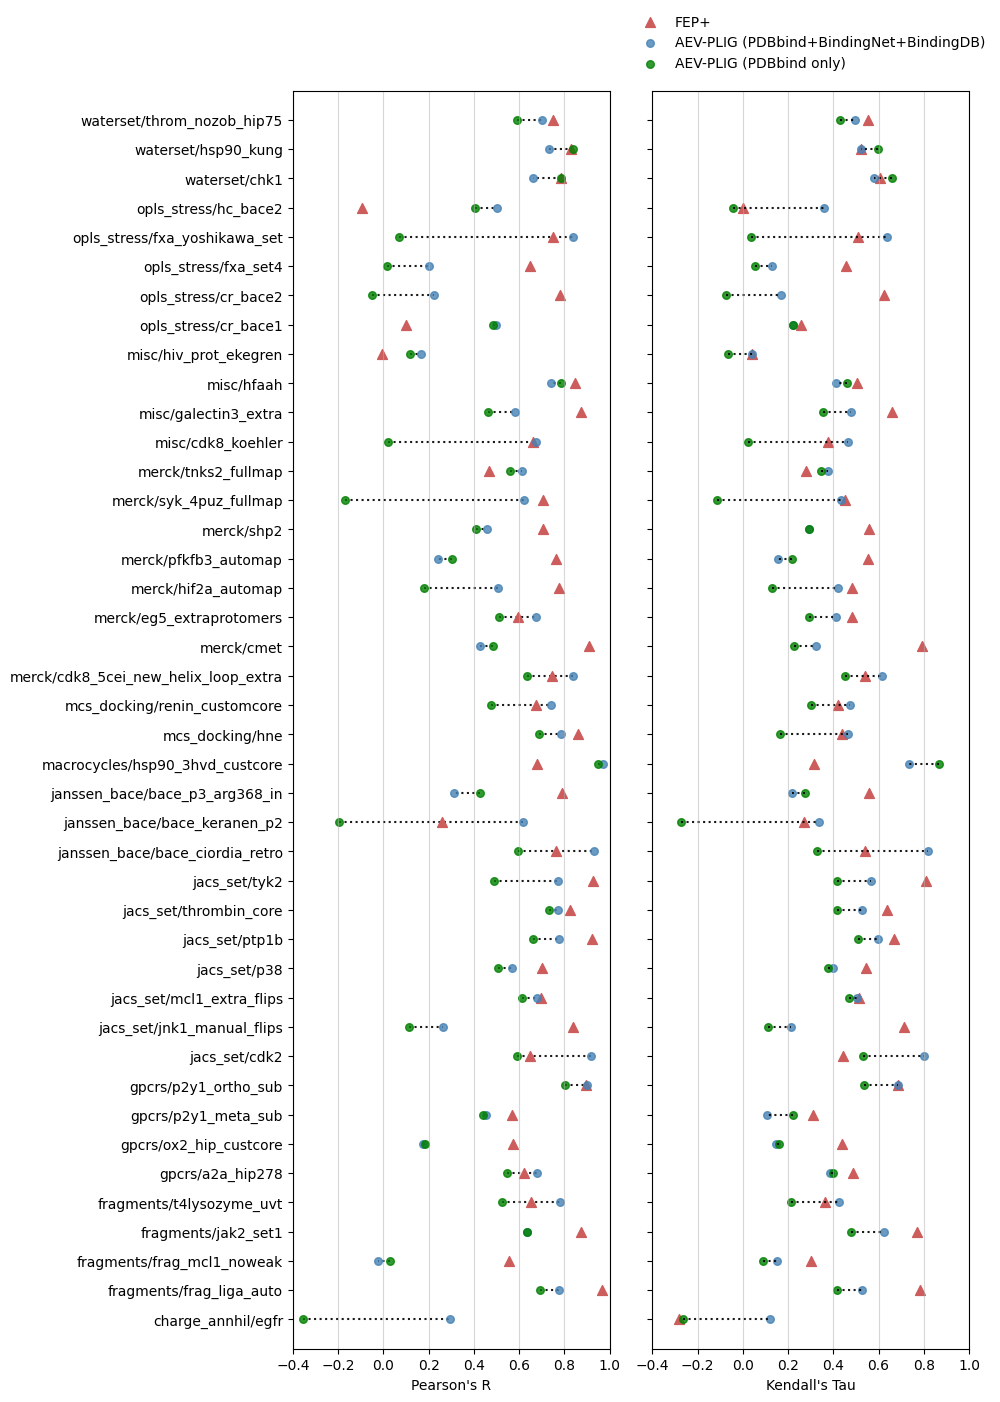

In [38]:
plot_dot_plot(
    groups,
    performance_fep,
    performance_aevplig,
    performance_baseline,
    outpath="figures/SI_figure2.png",
)

### Figure S3: Scatter plots for entire dataset vs series

In [41]:
def format_marginal(ax, horizontal=True):

        ax.set_xticks([])
        ax.set_yticks([])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        if horizontal:
            ax.spines['left'].set_visible(False)
            ax.invert_xaxis()
            
        else:
            ax.spines['bottom'].set_visible(False)
            ax.invert_yaxis()

        ax.set_ylabel('')
        ax.set_xlabel('')

def plot_scatter_with_marginals_2(df, group_metrics, x_col, y_col, group_col, outpath=None):

    fig = plt.figure(figsize=(3.8, 7), constrained_layout=True)

    widths = [4, 0.6]
    heights = [0.6, 4, 0.6, 4]
    lims = [-15, -3]

    spec = fig.add_gridspec(ncols=2, nrows=4, width_ratios=widths,
                        height_ratios=heights)
    
    # Dotted x=y line
    ax1 = fig.add_subplot(spec[1, 0])
    ax1.plot(lims, lims, linestyle='--', color='gray', alpha=0.7)

    ax2 = fig.add_subplot(spec[3, 0])
    ax2.plot(lims, lims, linestyle='--', color='gray', alpha=0.7)

    # Scatter plots
    sns.scatterplot(data=df, x=x_col, y=y_col, color='darkorange', ax=ax1, legend=False, edgecolor='black', alpha=0.6, zorder=10)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.set_xlabel('')
    ax1.set_ylabel(r'Pred. $\Delta$G (kcal/mol)')
    ax1.set_xticks([-14,-12,-10,-8,-6,-4])
    ax1.set_xlim(lims)
    ax1.set_yticks([-14,-12,-10,-8,-6,-4])
    ax1.set_ylim(lims)

    # Define color palette using tab20 and map group labels to colors
    palette = sns.color_palette("tab20")
    unique_groups = df[group_col].unique()
    group_to_color = {group: palette[i % len(palette)] for i, group in enumerate(unique_groups)}

    # Scatter plot with consistent colors
    sns.scatterplot(data=df, x=x_col, y=y_col, hue=group_col, palette=group_to_color, ax=ax2, legend=False,
                    edgecolor='black', alpha=0.6, zorder=10)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.set_xlabel(r'Exp. $\Delta$G (kcal/mol)')
    ax2.set_ylabel(r'Pred. $\Delta$G (kcal/mol)')
    ax2.set_xticks([-14, -12, -10, -8, -6, -4])
    ax2.set_xlim(lims)
    ax2.set_yticks([-14, -12, -10, -8, -6, -4])
    ax2.set_ylim(lims)

    # Marginal histograms
    ax1_marg_x = fig.add_subplot(spec[0, 0])
    sns.kdeplot(data=df, x=x_col, color='darkorange', ax=ax1_marg_x, legend=False)
    format_marginal(ax1_marg_x)
    ax1_marg_x.set_xlim(lims)

    ax1_marg_y = fig.add_subplot(spec[1, 1])
    sns.kdeplot(data=df, y=y_col, color='darkorange', ax=ax1_marg_y, legend=False)
    format_marginal(ax1_marg_y, horizontal=False)
    ax1_marg_y.set_ylim(lims)

    ax2_marg_x = fig.add_subplot(spec[2, 0])
    for group, data in df.groupby(group_col):
        colour = group_to_color[group] 
        sns.kdeplot(data=data, x=x_col, ax=ax2_marg_x, legend=False, color=colour)
    format_marginal(ax2_marg_x)
    ax2_marg_x.set_xlim(lims)

    ax2_marg_y = fig.add_subplot(spec[3, 1])
    for group, data in df.groupby(group_col):
        colour = group_to_color[group]
        sns.kdeplot(data=data, y=y_col, ax=ax2_marg_y, legend=False, color=colour)
    format_marginal(ax2_marg_y, horizontal=False)
    ax2_marg_y.set_ylim(lims)

    # Annotations
    ax1.set_title('a)', loc='left', position=(-0.2, 1.0), fontsize=12)
    ax2.set_title('b)', loc='left', position=(-0.2, 1.0), fontsize=12)

    ax1_pcc, ax1_kt, ax1_rmse = pearsonr(df[x_col], df[y_col])[0], kendalltau(df[x_col], df[y_col])[0], rmse(df[x_col], df[y_col])
    ax1.text(-14.5, -5, f'PCC = {ax1_pcc:.2f}\n'+r'K$\tau$ = '+f'{ax1_kt:.2f}\nRMSE = {ax1_rmse:.2f}', fontsize=9)

    ax2_pcc, ax2_kt, ax2_rmse = group_metrics[0], group_metrics[1], group_metrics[2]
    ax2.text(-14.5, -5, f'wmPCC = {ax2_pcc:.2f}\n'+r'wmK$\tau$ = '+f'{ax2_kt:.2f}\nwmRMSE = {ax2_rmse:.2f}', fontsize=9)

    if outpath:
        plt.tight_layout(w_pad=1, h_pad=0)
        plt.savefig(outpath, bbox_inches='tight')

In [43]:
results = pd.read_csv("data/fep/fep_benchmark_fep+_predictions.csv", index_col=0)
counts = pd.DataFrame(results["group_id"].value_counts())
groups = list(counts[counts["count"] >= 25].index)
fep_index = results[["graph_id", "Exp. dG (kcal/mol)"]]
fep_index = fep_index.rename(columns={"graph_id":"unique_id"})

results = pd.read_csv("data/baseline/AEV-PLIG_fep_benchmark_pdbbind_ligsim90_predictions.csv")
results["preds"] = [pk_to_dg(pk) for pk in results["preds"]]
results = results.merge(fep_index, how="left", on="unique_id")
results = results[results["group_id"].isin(groups)]

aevplig_data = get_performance_df(results, 'preds', 'Exp. dG (kcal/mol)', groups)

aev_wpcc = weighted_mean(np.array(aevplig_data["Sample size"]), np.array(aevplig_data["Pearson's R"]))
aev_wktau = weighted_mean(np.array(aevplig_data["Sample size"]), np.array(aevplig_data["Kendall's Tau"]))
aev_wrmse = weighted_mean(np.array(aevplig_data["Sample size"]), np.array(aevplig_data["RMSE"]))

/var/folders/n0/jnvj1pls2_5_j5b80078qmx40000gn/T/ipykernel_42805/3135779759.py:101: UserWarning: The figure layout has changed to tight
  plt.tight_layout(w_pad=1, h_pad=0)


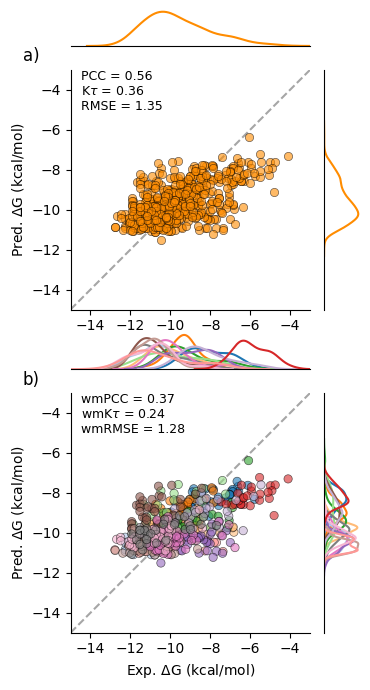

In [44]:
plot_scatter_with_marginals_2(results, [aev_wpcc, aev_wktau, aev_wrmse], 'Exp. dG (kcal/mol)', 'preds', 'group_id', outpath='figures/SI_figure3.png')

### Figure S4: AEV-PLIG performance on CASF-2016, OOD Test and 0 Ligand Bias

In [16]:
def pearson(true, pred):
    return pearsonr(true, pred)[0]

def kendall(true, pred):
    return kendalltau(true, pred)[0]

def generate_results(results, pred_col='pred', truth_col='pk'):
    preds = np.array(results[pred_col])
    truth = np.array(results[truth_col])

    pcc = pearson(preds, truth)
    ktau = kendall(preds, truth)

    results['pred'] = [pk_to_dg(pk) for pk in results[pred_col]]
    results['truth'] = [pk_to_dg(pk) for pk in results[truth_col]]
    preds = np.array(results['pred'])
    truth = np.array(results['truth'])
    return pcc, ktau

def plot_bars(df_baseline, df_augmented, column1="pcc", column2="ktau", xlabel='', y1_label='PCC', y2_label=r"Kendall's $\tau$", y1_lim=(0,1), y2_lim=(0,1), outpath=None):
    
    color = "steelblue"
    color_baseline = "green"

    labels = df_baseline.test_set
    x = [x for x in range(3)]
    
    bar_width = 0.35

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9,6), sharex=True, constrained_layout=True)
    
    bars1_1 = ax1.bar(x, df_baseline[column1], bar_width, label='PDBbind v2020', facecolor=color_baseline, edgecolor='black')
    bars1_2 = ax1.bar([i + bar_width for i in x], df_augmented[column1], bar_width, label='PBDbind v2020 + BindingNet + BindingDB-DCS', facecolor=color, edgecolor='black')

    bars2_1 = ax2.bar(x, df_baseline[column2], bar_width, label='PDBbind v2020', facecolor=color_baseline, edgecolor='black')
    bars2_2 = ax2.bar([i + bar_width for i in x], df_augmented[column2], bar_width, label='PBDbind v2020 + BindingNet + BindingDB-DCS', facecolor=color, edgecolor='black')

    ax1.set_ylim(y1_lim)
    ax2.set_ylim(y2_lim)

    ax1.set_ylabel(y1_label)
    ax2.set_ylabel(y2_label)

    ax2.set_xlabel(xlabel, labelpad=1)
    ax1.set_xticks([i + bar_width/2 for i in x])
    ax2.set_xticks([i + bar_width/2 for i in x])
    ax2.set_xticklabels(labels)
    ax1.legend(ncol=2, frameon=False, loc='upper center', bbox_to_anchor=(0.5, 1.15))

    ax1.set_title("a)", loc="left", fontsize=14, position=(-0.08, 1))
    ax2.set_title("b)", loc="left", fontsize=14, position=(-0.08, 1))

    if outpath:
        plt.tight_layout(pad=1)
        plt.savefig(outpath, dpi=500)

In [17]:
test_sets = ["CASF-2016", "OOD Test", "0 Ligand Bias"]
pccs = []
ktaus = []

results = pd.read_csv("data/bindingnet_bindingdb/AEV-PLIG_casf2016_pdbbind_U_bindingnet_U_bindingdb_predictions.csv")
pcc, ktau = generate_results(results, pred_col='preds', truth_col='pk')
pccs.append(pcc)
ktaus.append(ktau)

results = pd.read_csv("data/bindingnet_bindingdb/AEV-PLIG_oodtest_pdbbind_U_bindingnet_U_bindingdb_predictions.csv")
pcc, ktau = generate_results(results, pred_col='preds', truth_col='pK')
pccs.append(pcc)
ktaus.append(ktau)

results = pd.read_csv("data/bindingnet_bindingdb/AEV-PLIG_0ligandbias_pdbbind_U_bindingnet_U_bindingdb_predictions.csv")
pcc, ktau = generate_results(results, pred_col='preds', truth_col='pk')
pccs.append(pcc)
ktaus.append(ktau)

df_augmented = pd.DataFrame(data={"test_set":test_sets, "pcc":pccs, "ktau":ktaus})

# Create dataframe for baseline AEV-PLIG
test_sets = ["CASF-2016", "OOD Test", "0 Ligand Bias"]
pccs = []
ktaus = []
rmses = []

results = pd.read_csv("data/baseline/AEV-PLIG_casf2016_pdbbind_predictions.csv")
pcc, ktau = generate_results(results, pred_col='preds', truth_col='truth')
pccs.append(pcc)
ktaus.append(ktau)

results = pd.read_csv("data/baseline/AEV-PLIG_oodtest_predictions.csv")
pcc, ktau = generate_results(results, pred_col='preds', truth_col='pK')
pccs.append(pcc)
ktaus.append(ktau)

results = pd.read_csv("data/baseline/AEV-PLIG_0ligandbias_pdbbind_predictions.csv")
pcc, ktau = generate_results(results, pred_col='preds', truth_col='truth')
pccs.append(pcc)
ktaus.append(ktau)

df_baseline = pd.DataFrame(data={"test_set":test_sets, "pcc":pccs, "ktau":ktaus})

/var/folders/n0/jnvj1pls2_5_j5b80078qmx40000gn/T/ipykernel_64881/1888756216.py:54: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=1)


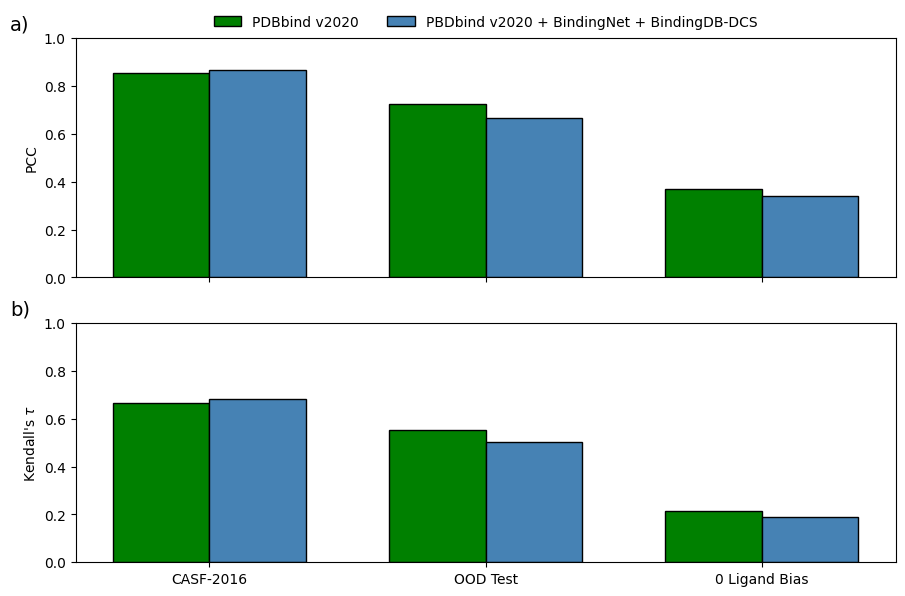

In [18]:
plot_bars(
    df_baseline,
    df_augmented, 
    outpath="figures/SI_figure4.png"
)

### Figure S5: AEV-PLIG performance vs augmented dataset size

In [12]:
def plot_lineplot_augmented(
    df,
    pcc_lims,
    ktau_lims,
    pcc_ticks,
    ktau_ticks,
    xlabel,
    invert_xaxis=False,
    outpath=None,
):
    color = "steelblue"
    fig = plt.figure(figsize=(3.8, 8))
    gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1])

    ax1 = plt.subplot(gs[0])
    ax2 = plt.subplot(gs[1], sharex=ax1)

    # plot PCC data
    sns.lineplot(
        data = df,
        x="Percent",
        y="WPCC",
        color=color,
        marker="o",
        ms=10,
        lw=2,
        markeredgecolor="black",
        markeredgewidth=1.1,
        ax=ax1
    )
    errors = np.array([df["WPCC"] - df["WPCC_low"], df["WPCC_high"] - df["WPCC"]])
    ax1.errorbar(df["Percent"], df["WPCC"], yerr=errors, fmt='o', capsize=4, elinewidth=1.5, ecolor=color, capthick=1.5, zorder=0)

    # plot Ktau data
    sns.lineplot(
        data = df,
        x="Percent",
        y="WKtau",
        color=color,
        marker="o",
        ms=10,
        lw=2,
        markeredgecolor="black",
        markeredgewidth=1.1,
        ax=ax2,
        legend=False
    )
    errors = np.array([df["WKtau"] - df["WKtau_low"], df["WKtau_high"] - df["WKtau"]])
    ax2.errorbar(df["Percent"], df["WKtau"], yerr=errors, fmt='o', capsize=4, elinewidth=1.5, ecolor=color, capthick=1.5, zorder=0)

    ax1.set_ylabel("Weighted mean PCC")
    ax1.set_xlabel("")
    ax1.set_ylim(pcc_lims)
    ax1.set_yticks(pcc_ticks)
    ax1.set_xticks(["0","10","20","30","40","50","60","70","80","90","100"])
    ax1.set_title("a)", loc="left", fontsize=14, position=(-0.25, 1.0))

    ax2.set_xlabel(xlabel)
    ax2.set_ylabel(r"Weighted mean K$\tau$")
    ax2.set_ylim(ktau_lims)
    ax2.set_yticks(ktau_ticks)
    ax2.set_xticks(["0","10","20","30","40","50","60","70","80","90","100"])
    ax2.set_title("b)", loc="left", fontsize=14, position=(-0.25, 1.0))

    plt.tight_layout()

    if outpath:
        plt.savefig(outpath)

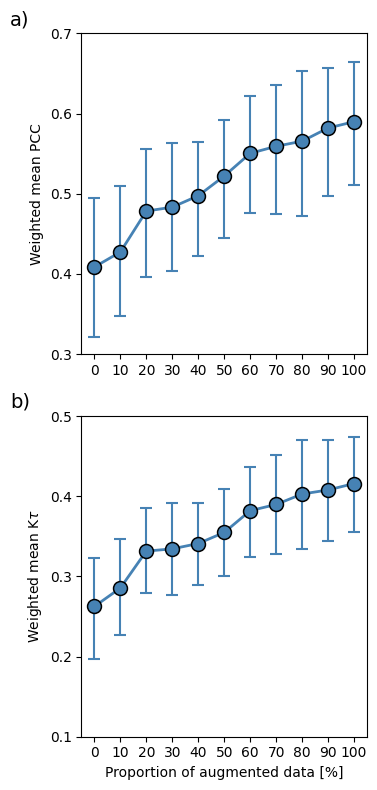

In [14]:
plot_lineplot_augmented(
    df,
    [0.3, 0.7],
    [0.1, 0.5],
    [0.3, 0.4, 0.5, 0.6, 0.7],
    [0.1, 0.2, 0.3, 0.4, 0.5],
    xlabel="Proportion of augmented data [%]",
    invert_xaxis=True,
    outpath="figures/SI_figure5.png",
)

### Figure S6: Scatter plots for each series

In [45]:
results_fep = pd.read_csv('data/fep/fep_benchmark_fep+_predictions.csv')
counts = pd.DataFrame(results_fep["group_id"].value_counts())
groups = list(counts[counts["count"] >= 25].index)
groups.remove('jacs_set/bace')
fep_index = results_fep[["graph_id", "Exp. dG (kcal/mol)"]]
fep_index = fep_index.rename(columns={"graph_id":"unique_id"})

results = pd.read_csv("data/bindingnet_bindingdb/AEV-PLIG_fep_benchmark_pdbbind_U_bindingnet_U_bindingdb_ligsim90_predictions.csv")
results["preds"] = [pk_to_dg(pk) for pk in results["preds"]]
results = results.merge(fep_index, how="left", on="unique_id")

target_dict = {'gpcrs/ox2_hip_custcore':'OX2',
 'merck/syk_4puz_fullmap':'SYK',
 'jacs_set/mcl1_extra_flips':'Mcl1',
 'merck/hif2a_automap':'HIF2α',
 'merck/pfkfb3_automap':'PFKFB3',
 'jacs_set/p38':'p38',
 'merck/eg5_extraprotomers':'Eg5',
 'janssen_bace/bace_ciordia_retro':'BACE1',
 'merck/tnks2_fullmap':'TNKS2',
 'merck/cdk8_5cei_new_helix_loop_extra':'CDK8',
 'mcs_docking/renin_customcore':'Renin',
 'opls_stress/fxa_yoshikawa_set':'Factor Xa',
 'misc/galectin3_extra':'Galectin',
 'merck/shp2':'SHP-2'}

# Shift predictions
for group in groups:
    subset = results[results['group_id'] == group]
    mean_exp = subset['Exp. dG (kcal/mol)'].mean()
    mean_pred = subset['preds'].mean()
    shift_value = mean_exp - mean_pred
    results.loc[results['group_id'] == group, 'preds'] += shift_value

def plot_scatter_series(results, results_fep, groups, target_dict, outpath=None):

    fep_colour = 'indianred'
    aev_colour = 'steelblue'

    num_plots = len(groups)
    num_cols = 3
    num_rows = (num_plots + num_cols - 1) // num_cols

    # Ensure each plot is square
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 4 * num_rows))
    axes = axes.flatten()

    for i, group in enumerate(groups):
        subset_results = results[results['group_id'] == group]
        subset_fep = results_fep[results_fep['group_id'] == group]
        
        ax = axes[i]
        sns.scatterplot(x='Exp. dG (kcal/mol)', y='preds', data=subset_results, ax=ax, label='AEV-PLIG', color=aev_colour, alpha=0.7, s=50, edgecolor=None)
        sns.scatterplot(x='Exp. dG (kcal/mol)', y='Pred. dG (kcal/mol)', data=subset_fep, ax=ax, label='FEP+', color=fep_colour, alpha=0.7, s=50, edgecolor=None)
        
        # Calculate PCC
        pcc_results, _ = pearsonr(subset_results['Exp. dG (kcal/mol)'], subset_results['preds'])
        pcc_fep, _ = pearsonr(subset_fep['Exp. dG (kcal/mol)'], subset_fep['Pred. dG (kcal/mol)'])

        kendalltau_results, _ = kendalltau(subset_results['Exp. dG (kcal/mol)'], subset_results['preds'])
        kendalltau_fep, _ = kendalltau(subset_fep['Exp. dG (kcal/mol)'], subset_fep['Pred. dG (kcal/mol)'])
        
        ax.set_title(f"{target_dict[group]}")

        # Only plot x label for bottom row 
        ax.set_xlabel('Exp. dG (kcal/mol)')
        ax.set_ylabel('Pred. dG (kcal/mol)')

        ax.legend(loc="upper left")
        
        # Add text box with PCC and Kendall's Tau
        ax.text(0.50, 0.10, f'PCC: {pcc_results:.2f}'+r'   K$\tau$: '+f'{kendalltau_results:.2f}', transform=ax.transAxes, fontsize=10, verticalalignment='bottom', color=aev_colour)
        ax.text(0.50, 0.05, f'PCC: {pcc_fep:.2f}'+r'   K$\tau$: '+f'{kendalltau_fep:.2f}', transform=ax.transAxes, fontsize=10, verticalalignment='bottom', color=fep_colour)
                
        # Ensure the range of values on the y axes are the same as on the x axes
        min_val = min(subset_results['Exp. dG (kcal/mol)'].min() - 2, subset_fep['Exp. dG (kcal/mol)'].min() - 2)
        max_val = max(subset_results['Exp. dG (kcal/mol)'].max() + 2, subset_fep['Exp. dG (kcal/mol)'].max() + 2)
        ax.set_xlim(min_val, max_val)
        ax.set_ylim(min_val, max_val)
        ax.plot([min_val, max_val], [min_val, max_val], '--', c='grey', zorder=0)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()

    if outpath:
        plt.tight_layout(w_pad=1, h_pad=0)
        plt.savefig(outpath, bbox_inches='tight')

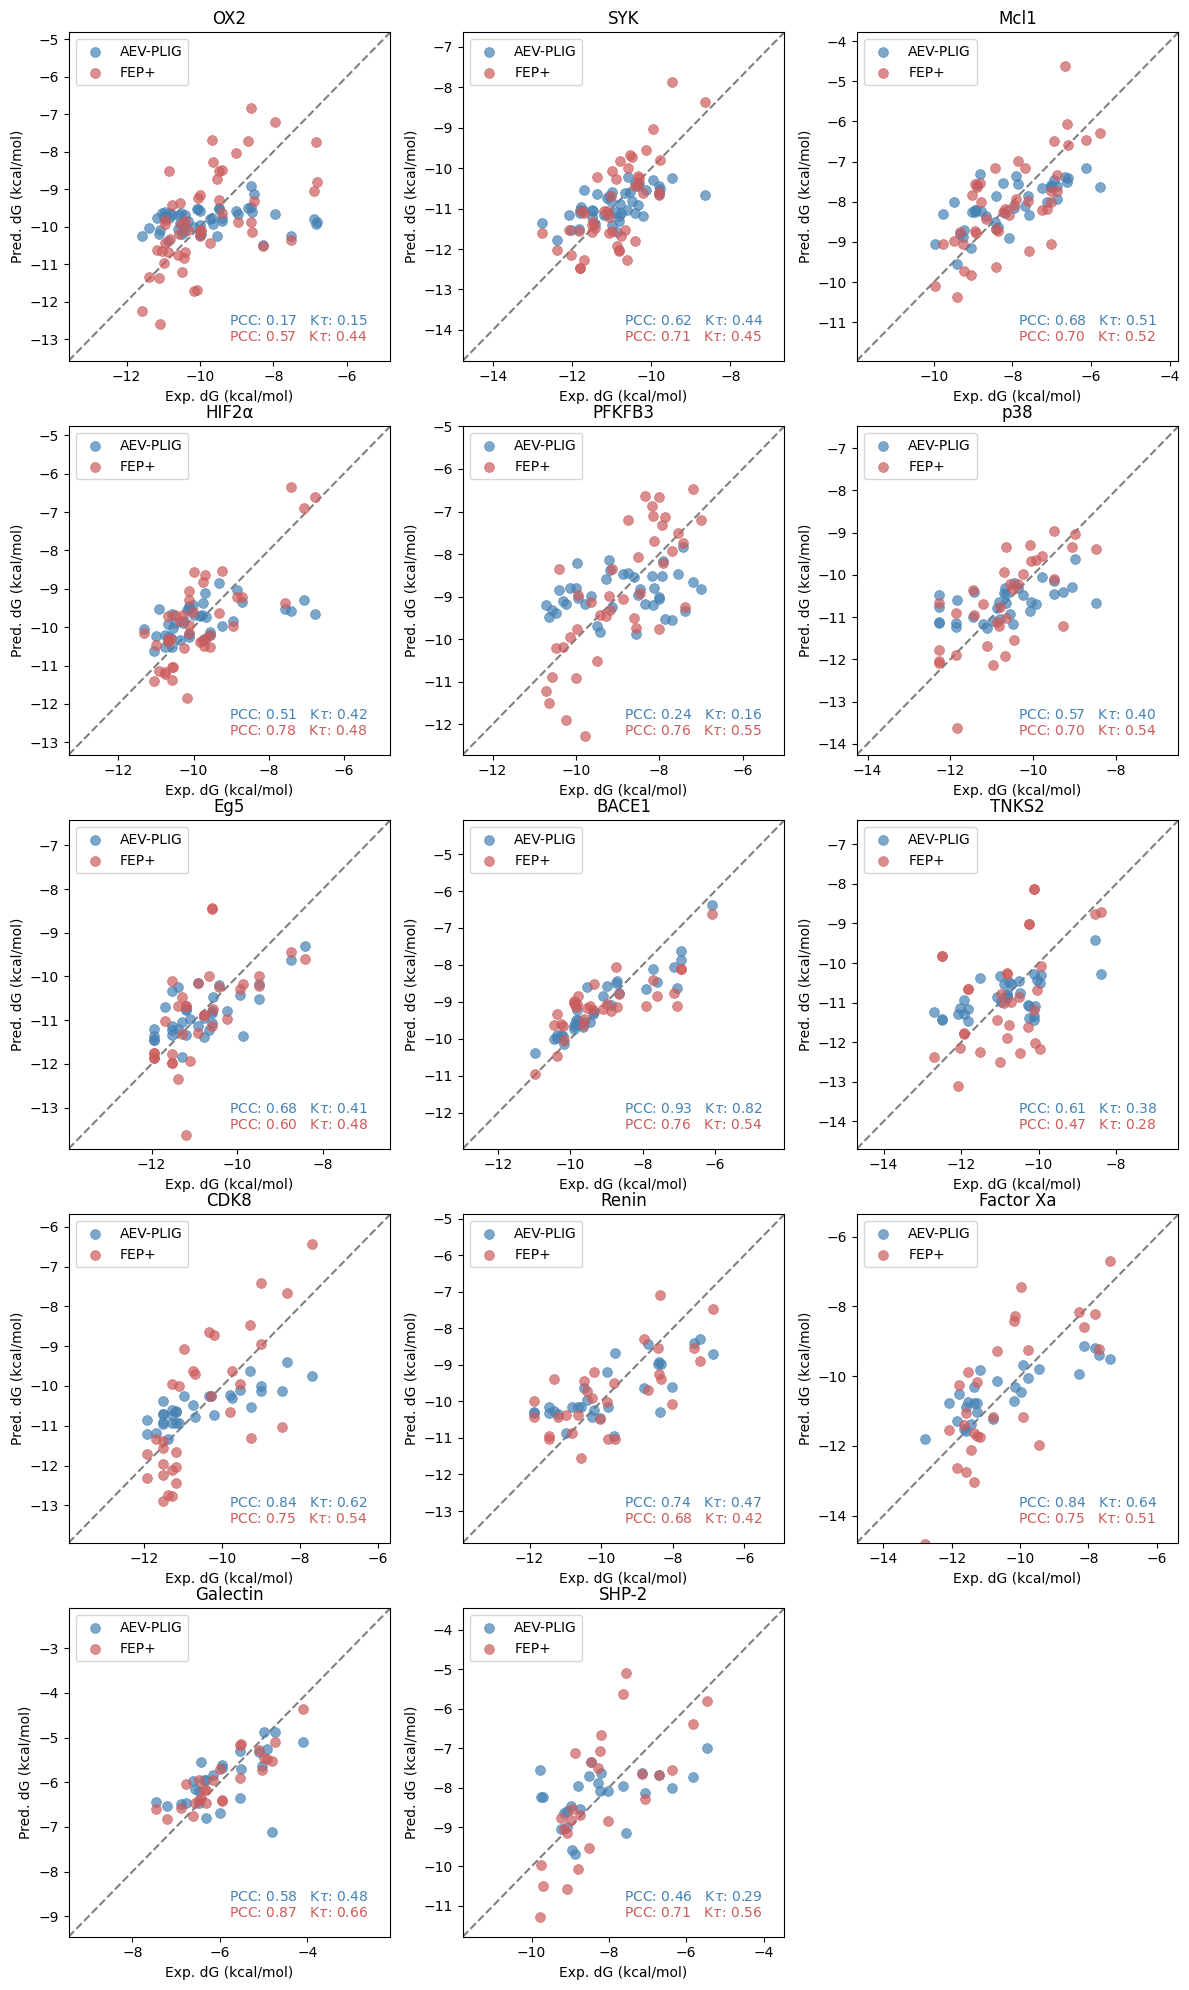

In [46]:
plot_scatter_series(results, results_fep, groups, target_dict, outpath='figures/SI_figure6.png')

In [13]:
x_axis = ["0","10","20","30","40","50","60","70","80","90","100"]

fep_index = pd.read_csv('data/fep/fep_benchmark_fep+_predictions.csv', index_col=0)
fep_index = fep_index.rename(columns={"graph_id":"unique_id"})
counts = pd.DataFrame(fep_index["group_id"].value_counts())
groups = list(counts[counts["count"] >= 10].index)

wpcc = []
wpcc_low = []
wpcc_high = []
wktau = []
wktau_low = []
wktau_high = []

results = pd.read_csv('data/baseline/AEV-PLIG_fep_benchmark_pdbbind_ligsim90_predictions.csv', index_col=0)
results["preds"] = pk_to_dg(results["preds"])
results = results.merge(fep_index[["unique_id", "Exp. dG (kcal/mol)"]], how="left", on="unique_id")
performance = get_performance_df(results, 'preds', 'Exp. dG (kcal/mol)', groups)

wpcc.append(weighted_mean(np.array(performance["Sample size"]), np.array(performance["Pearson's R"])))
ci = get_bootstrap_weighted_value(np.array(performance["Sample size"]), np.array(performance["Pearson's R"]))
wpcc_low.append(ci[0])
wpcc_high.append(ci[1])

wktau.append(weighted_mean(np.array(performance["Sample size"]), np.array(performance["Kendall's Tau"])))
ci = get_bootstrap_weighted_value(np.array(performance["Sample size"]), np.array(performance["Kendall's Tau"]))
wktau_low.append(ci[0])
wktau_high.append(ci[1])

for i in range(1,10):
    add = str(i) + '0'
    results = pd.read_csv('data/augmented_data_test/AEV-PLIG_fep_benchmark_pdbbind_U_bindingnet_U_bindingdb_ligsim90_' + add + 'percent' + '_predictions.csv')
    results["preds"] = pk_to_dg(results["preds"])
    performance = get_performance_df(results, 'preds', 'Exp. dG (kcal/mol)', groups)
    
    wpcc.append(weighted_mean(np.array(performance["Sample size"]), np.array(performance["Pearson's R"])))
    ci = get_bootstrap_weighted_value(np.array(performance["Sample size"]), np.array(performance["Pearson's R"]))
    wpcc_low.append(ci[0])
    wpcc_high.append(ci[1])

    wktau.append(weighted_mean(np.array(performance["Sample size"]), np.array(performance["Kendall's Tau"])))
    ci = get_bootstrap_weighted_value(np.array(performance["Sample size"]), np.array(performance["Kendall's Tau"]))
    wktau_low.append(ci[0])
    wktau_high.append(ci[1])

results = pd.read_csv('data/bindingnet_bindingdb/AEV-PLIG_fep_benchmark_pdbbind_U_bindingnet_U_bindingdb_ligsim90_predictions.csv', index_col=0)
results["preds"] = pk_to_dg(results["preds"])
results = results.merge(fep_index[["unique_id", "Exp. dG (kcal/mol)"]], how="left", on="unique_id")
performance = get_performance_df(results, 'preds', 'Exp. dG (kcal/mol)', groups)

wpcc.append(weighted_mean(np.array(performance["Sample size"]), np.array(performance["Pearson's R"])))
ci = get_bootstrap_weighted_value(np.array(performance["Sample size"]), np.array(performance["Pearson's R"]))
wpcc_low.append(ci[0])
wpcc_high.append(ci[1])

wktau.append(weighted_mean(np.array(performance["Sample size"]), np.array(performance["Kendall's Tau"])))
ci = get_bootstrap_weighted_value(np.array(performance["Sample size"]), np.array(performance["Kendall's Tau"]))
wktau_low.append(ci[0])
wktau_high.append(ci[1])

df = pd.DataFrame(
    {
        "Percent": x_axis,
        "WPCC": wpcc,
        "WPCC_low": wpcc_low,
        "WPCC_high": wpcc_high,
        "WKtau": wktau,
        "WKtau_low": wktau_low,
        "WKtau_high": wktau_high
    }
)